# Genre-specific city histories

## tl;dr

Wikidata supplies at least one genre for **924/1000
bands (92%)** and an inception year for
**822/1000
(82%)**. After FUA mapping, **599 bands**
have both fields. **Rock and indie** is the largest broad family in the observed
formation-decade data. The results support an exploratory genre history, but
the taxonomy is a transparent reduction of community-authored Wikidata labels,
not a definitive classification.

## Context and methods

The study review proposes genre-specific histories rather than treating all
bands as one production system. This experiment uses the popularity-first top
1,000, accepted FUA mappings, Wikidata `genre` (`P136`) claims and Wikidata
`inception` (`P571`) dates.

Genre labels are mapped into six broad families. A band with labels in several
families contributes fractional credit summing to one, preventing multi-tagged
bands from inflating totals.

### Assumptions

Wikidata labels are community-maintained and uneven in specificity. Formation
year marks a cohort, not the date a city developed a scene. Current Spotify
followers are retained only as context and are not interpreted as historical
audience.

Source documentation: [Wikidata API](https://www.mediawiki.org/wiki/Wikibase/API).

## Data

Rebuild the audit from the frozen Wikidata entity capture.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "src/python_uk_bands").exists():
    ROOT = next(
        parent for parent in Path.cwd().resolve().parents
        if (parent / "src/python_uk_bands").exists()
    )
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

ARTIFACT_DIR = ROOT / "artifacts/experiments/genre_city_histories/20260725"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
from python_uk_bands.review_extension_experiments import (
    build_genre_history,
    plot_city_genre_mix,
    plot_genre_by_decade,
)

WIKIDATA_PATH = ROOT / "data/raw/wikidata/review_extension_entities_20260725.json"
band_audit, city_genre, decade_genre, coverage = build_genre_history(
    ROOT, wikidata_path=WIKIDATA_PATH
)

assert len(band_audit) == 1000
assert band_audit["popularity_rank"].is_unique
assert 0 <= coverage["genre_coverage"] <= 1
assert 0 <= coverage["inception_year_coverage"] <= 1
assert city_genre.groupby("study_city_label")["genre_share"].sum().round(10).eq(1).all()

band_audit.to_csv(ARTIFACT_DIR / "band_genre_year_audit.csv", index=False)
city_genre.to_csv(ARTIFACT_DIR / "city_genre_summary.csv", index=False)
decade_genre.to_csv(ARTIFACT_DIR / "decade_genre_summary.csv", index=False)
(ARTIFACT_DIR / "coverage_summary.json").write_text(
    json.dumps(coverage, indent=2, sort_keys=True) + "\n"
)

display(Markdown(
    f"**{coverage['bands_with_genre']}/{coverage['selected_bands']} genres · "
    f"{coverage['bands_with_inception_year']}/{coverage['selected_bands']} inception years · "
    f"{coverage['mapped_bands_with_genre_and_year']} mapped bands with both**"
))

**924/1000 genres · 822/1000 inception years · 599 mapped bands with both**

## Results

### 1. Which broad genre families appear in each formation decade?

formation_decade,genre_family,weighted_bands,distinct_bands,weighted_followers
1950,Other genres,2.00,2,"217,664"
1950,Rock and indie,1.50,2,"163,506"
1950,"Pop, soul and R&B",0.50,1,"126,248"
1960,Rock and indie,35.17,51,"78,167,623"
1960,"Pop, soul and R&B",12.00,22,"32,264,326"
1960,Other genres,8.83,17,"46,193,928"
1960,Metal,3.33,6,"15,053,766"
1960,Electronic and dance,0.33,1,"675,042"
1960,Punk and new wave,0.33,1,"986,103"
1970,Punk and new wave,47.67,64,"29,049,067"


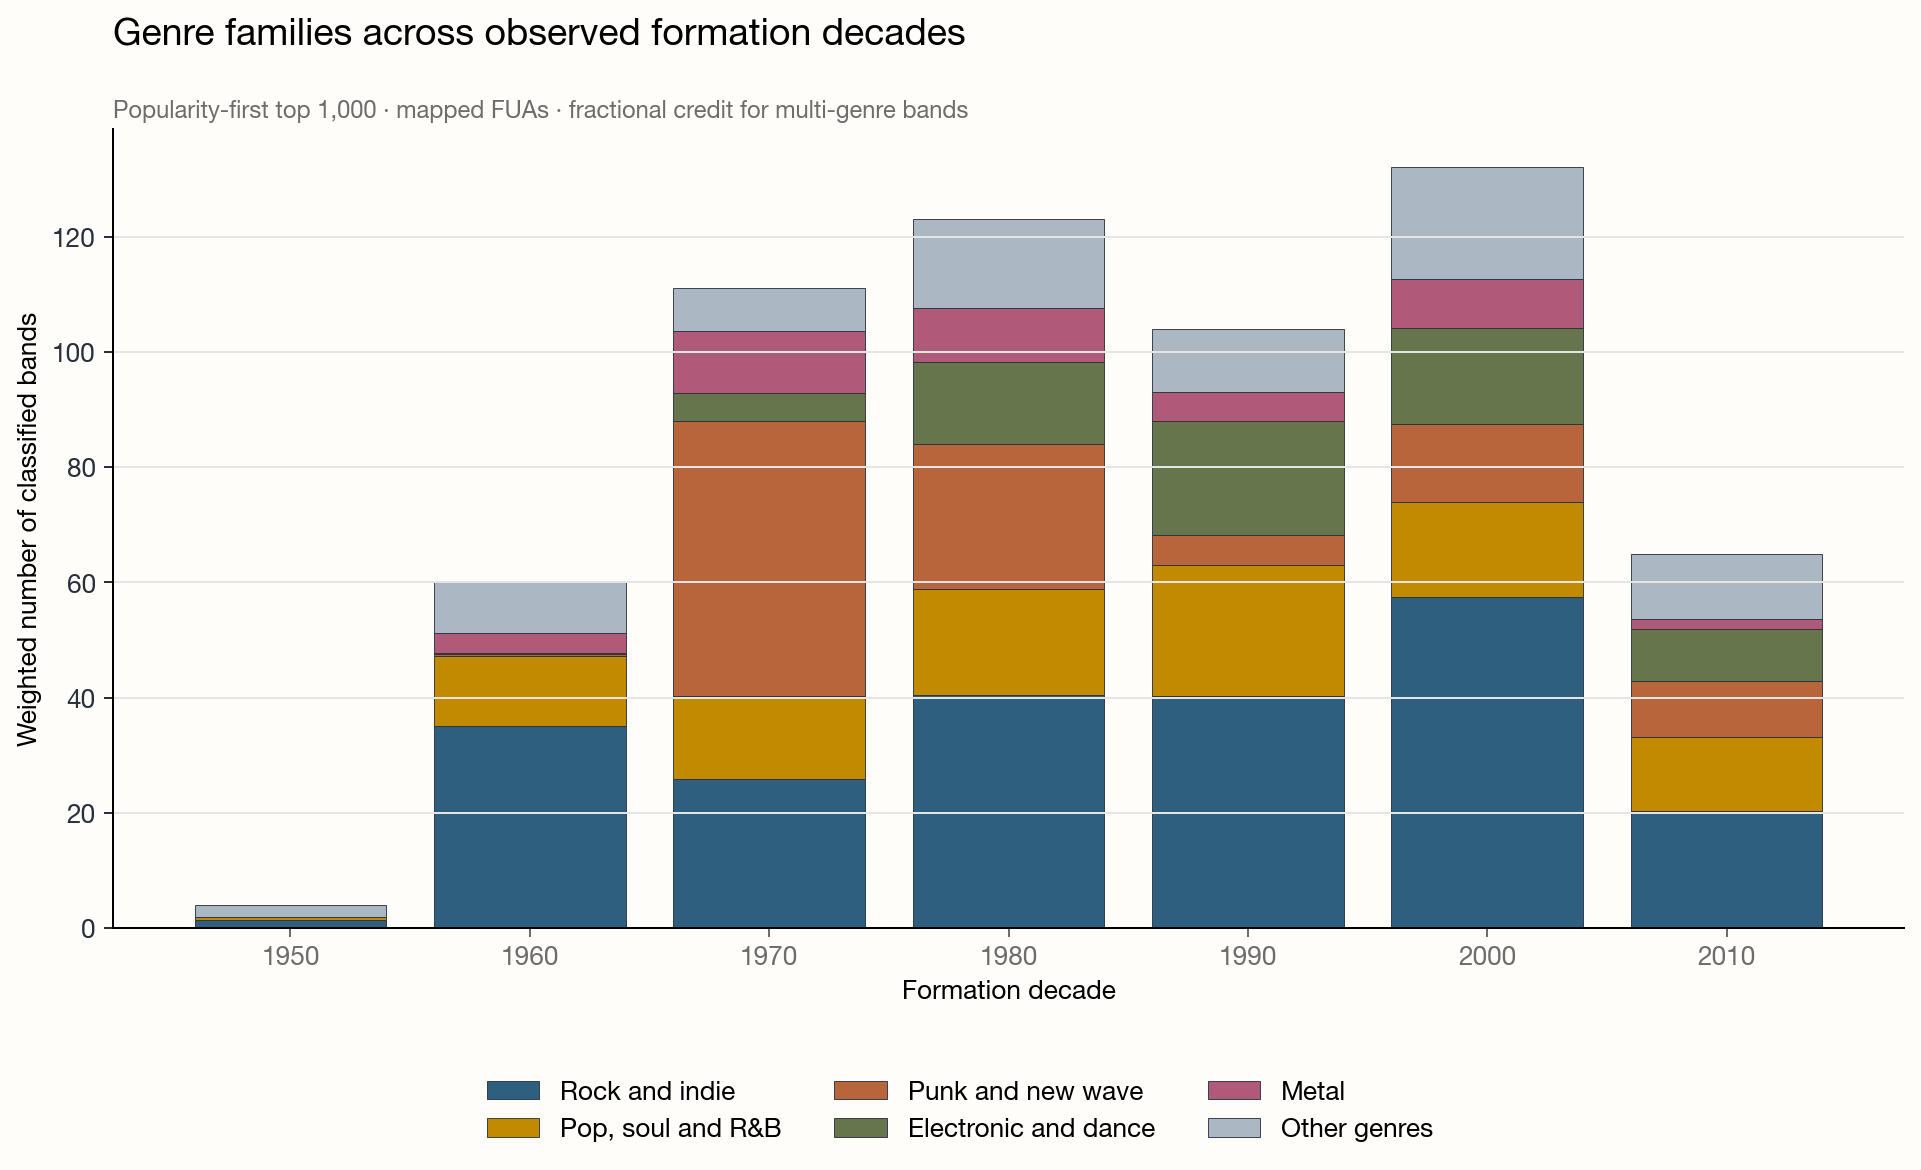

In [3]:
display(decade_genre.sort_values(
    ["formation_decade", "weighted_bands"], ascending=[True, False]
).style.hide(axis="index").format({
    "weighted_bands": "{:.2f}",
    "weighted_followers": "{:,.0f}",
}))

decade_path = plot_genre_by_decade(
    decade_genre,
    output_path=ARTIFACT_DIR / "chart_01_genre_by_decade.png",
)
display(Image(filename=str(decade_path)))

### 2. How different are the genre mixes of the best-covered FUAs?

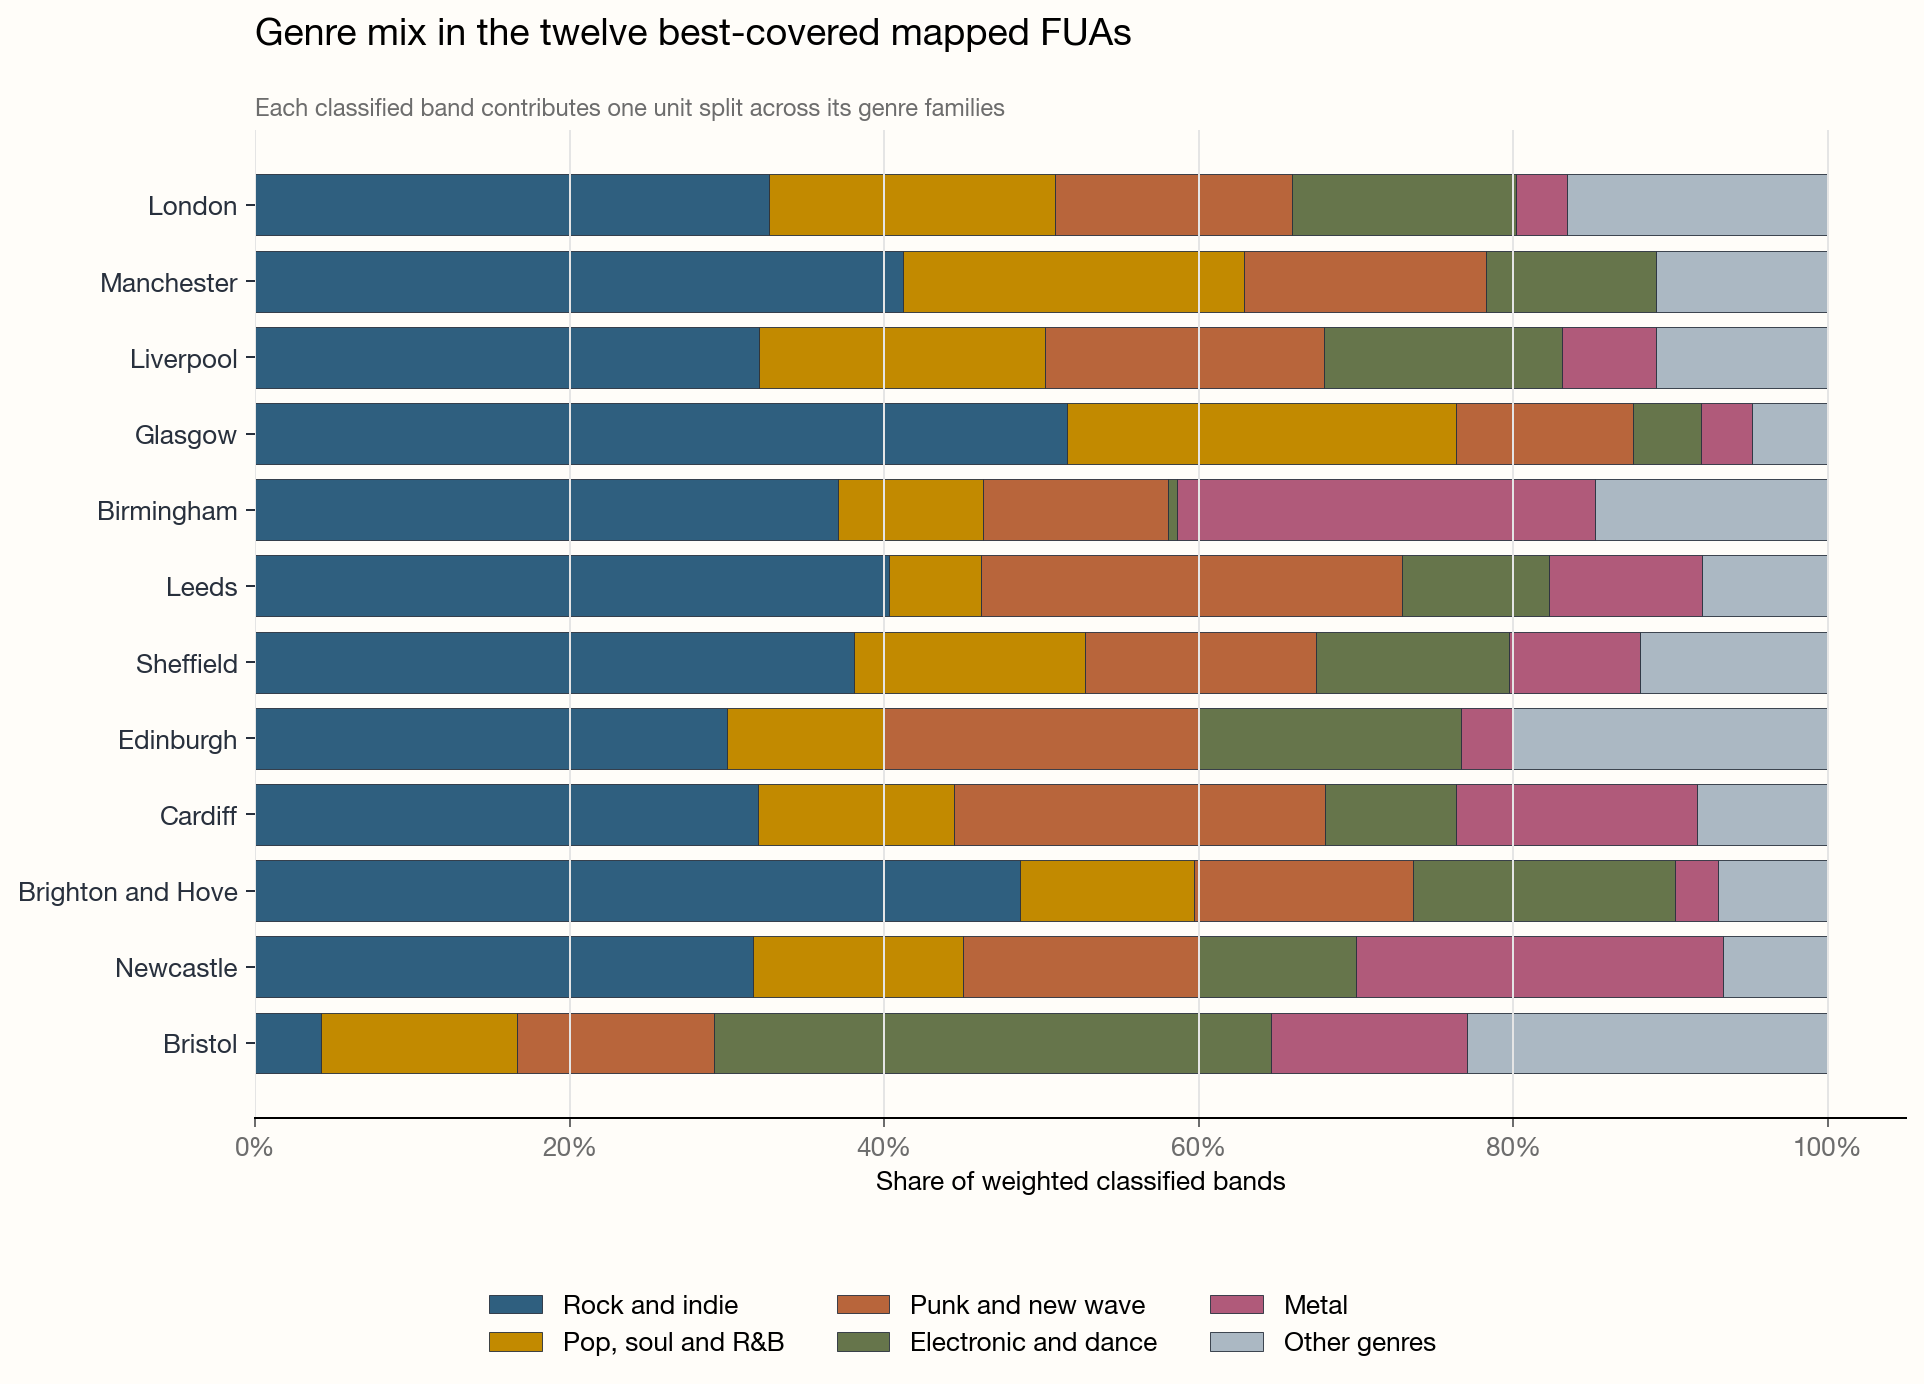

study_city_label,genre_family,weighted_bands,distinct_bands,weighted_followers,genre_share
Bath and North East Somerset,Punk and new wave,1.00,1,"4,593,372",50.0%
Bath and North East Somerset,Rock and indie,1.00,1,"516,287",50.0%
Bedford,"Pop, soul and R&B",1.00,1,"285,868",100.0%
Belfast,Rock and indie,1.50,2,"1,483,038",37.5%
Belfast,Other genres,1.00,1,"558,490",25.0%
Belfast,Punk and new wave,1.00,1,"236,374",25.0%
Belfast,"Pop, soul and R&B",0.50,1,"1,327,862",12.5%
Birmingham,Rock and indie,10.00,15,"8,769,106",37.0%
Birmingham,Metal,7.17,9,"11,605,614",26.5%
Birmingham,Other genres,4.00,7,"3,850,908",14.8%


In [4]:
mix_path = plot_city_genre_mix(
    city_genre,
    output_path=ARTIFACT_DIR / "chart_02_city_genre_mix.png",
)
display(Image(filename=str(mix_path)))

display(city_genre.sort_values(
    ["study_city_label", "genre_share"], ascending=[True, False]
).style.hide(axis="index").format({
    "weighted_bands": "{:.2f}",
    "weighted_followers": "{:,.0f}",
    "genre_share": "{:.1%}",
}))

## Takeaways

- Genre and formation-year coverage are high enough for a transparent
  exploratory description of the popularity-first top 1,000.
- Broad family assignments make city differences readable but discard
  important distinctions such as post-punk versus punk or trip hop versus
  electronic music.
- Multi-genre bands receive fractional credit; totals therefore describe band
  equivalents rather than raw tag counts.
- A publishable genre history still needs reviewed genre decisions and
  population denominators for each formation decade.